# 轮廓信息
- 轮廓信息说明
- 轮廓属性
- 旋转后提取最小矩形

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## 轮廓信息
轮廓信息可以简单的理解为图像曲线的连接点信息，在目标检测以及识别中有一定的作用。

轮廓信息的查找最好是基于灰度图像或者边缘特征图像，因为基于这样的图像比较容易找连接点信息；<br/>
NOTE: 在 OpenCV 中，查找轮廓是在黑色背景中查找白色图像的轮廓信息。

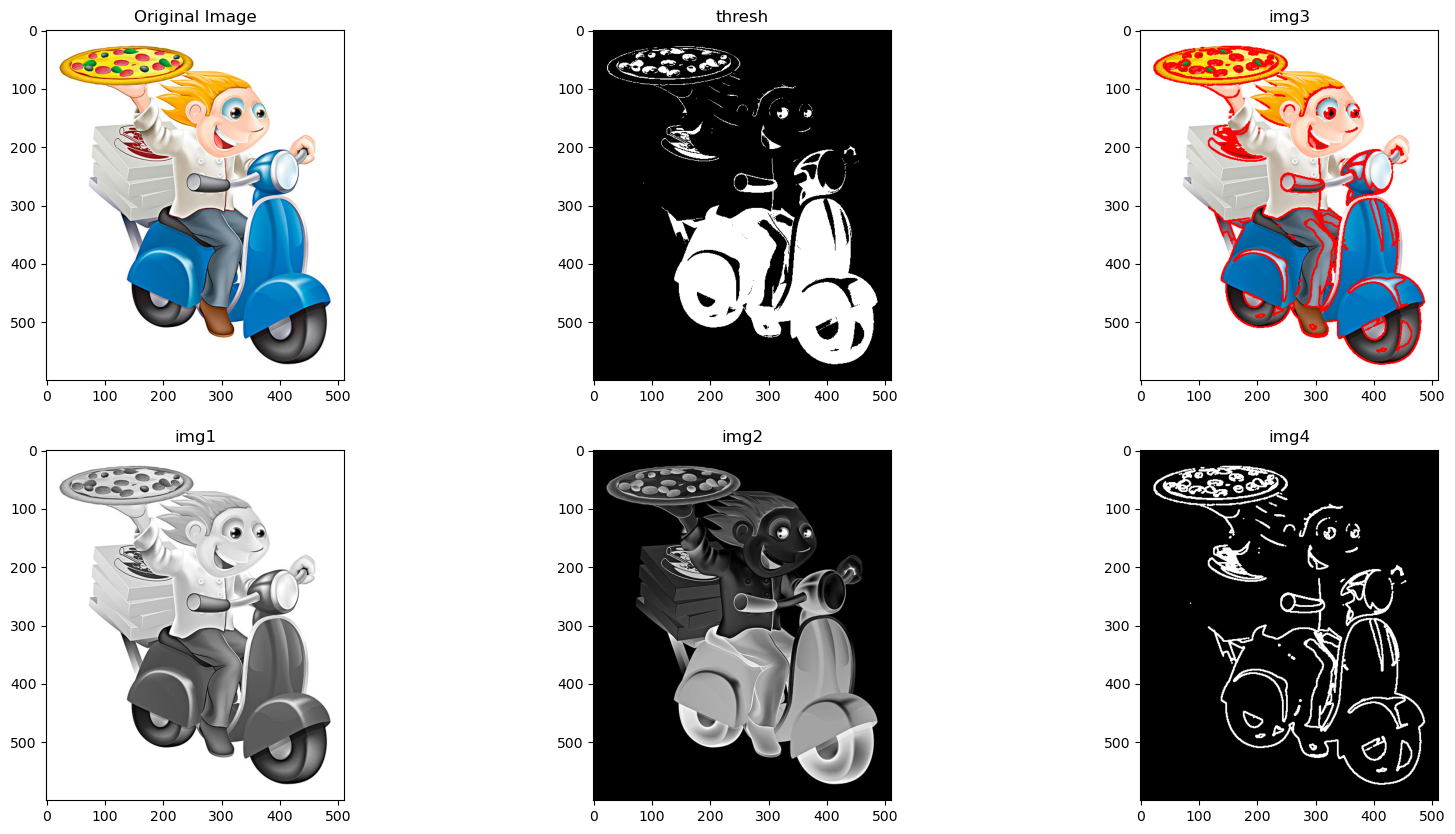

In [2]:
# 加载图像
img = cv.imread('./images/xiaoren.png')

# 转换为灰度图
img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做一个图像反转 (0 -> 255, 255 -> 0)
img2 = cv.bitwise_not(img1)

# 做一个二值化
ret, thresh = cv.threshold(img2, 127, 255, cv.THRESH_BINARY)

# 发现轮廓信息
# cv.RETR_TREE：检测所有轮廓并建立完整的层级树（轮廓的检索模型）
# CHAIN_APPROX_NONE：保留所有点（轮廓的近似方法）
# contours：每个轮廓的坐标点信息
# hierarchy: 轮廓之间的关系
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)
# print(type(contours))  # <class 'tuple'>
# print(contours[0])
"""
[[[439 548]]

 [[440 547]]

 [[441 548]]

 [[440 549]]]
"""
# print(hierarchy.shape)  # (1, 283, 4)

# 在图像中绘制轮廓（红线）
img3 = np.copy(img)
# contourIdx=-1：绘制所有轮廓
cv.drawContours(img3, contours, contourIdx=-1, color=(0, 0, 255), thickness=2)

# 绘制点最多的轮廓
# 计算点最多的轮廓的索引
# max_idx = np.argmax([len(t) for t in contours])
# cv.drawContours(img3, contours, contourIdx=max_idx, color=(0, 0, 255), thickness=2)

# 将轮廓当成边缘（白线）
# 创建黑色图像
img4 = np.zeros_like(img3)
# contourIdx=-1：绘制所有轮廓
cv.drawContours(img4, contours, contourIdx=-1, color=(255, 255, 255), thickness=2)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(231)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(232)
plt.imshow(thresh, cmap='gray')  # 二值化
plt.title('thresh')

plt.subplot(233)
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))  # 在图像中绘制轮廓
plt.title('img3')

plt.subplot(234)
plt.imshow(img1, cmap='gray')  # 灰度图
plt.title('img1')

plt.subplot(235)
plt.imshow(img2, cmap='gray')  # 反转后的灰度图
plt.title('img2')

plt.subplot(236)
plt.imshow(img4, cmap='gray')  # 将轮廓当成边缘
plt.title('img4')

plt.show()

In [3]:
print("总的轮廓数目：", len(contours))

总的轮廓数目： 283


In [4]:
# (1, 283, 4)
# 1：轮廓检索模式下的 轮廓组数量
# 283：检测到的 轮廓总数
# 4：每个轮廓的 层级信息，由 4 个整数值组成，格式为：[Next, Previous, First_Child, Parent]

# 具体含义：
# Next：同一层级中的下一个轮廓索引（-1 表示无）
# Previous：同一层级中的上一个轮廓索引（-1 表示无）
# First_Child：第一个子轮廓索引（-1 表示无）
# Parent：父轮廓索引（-1 表示无）
hierarchy.shape  # 轮廓之间的关系

(1, 283, 4)

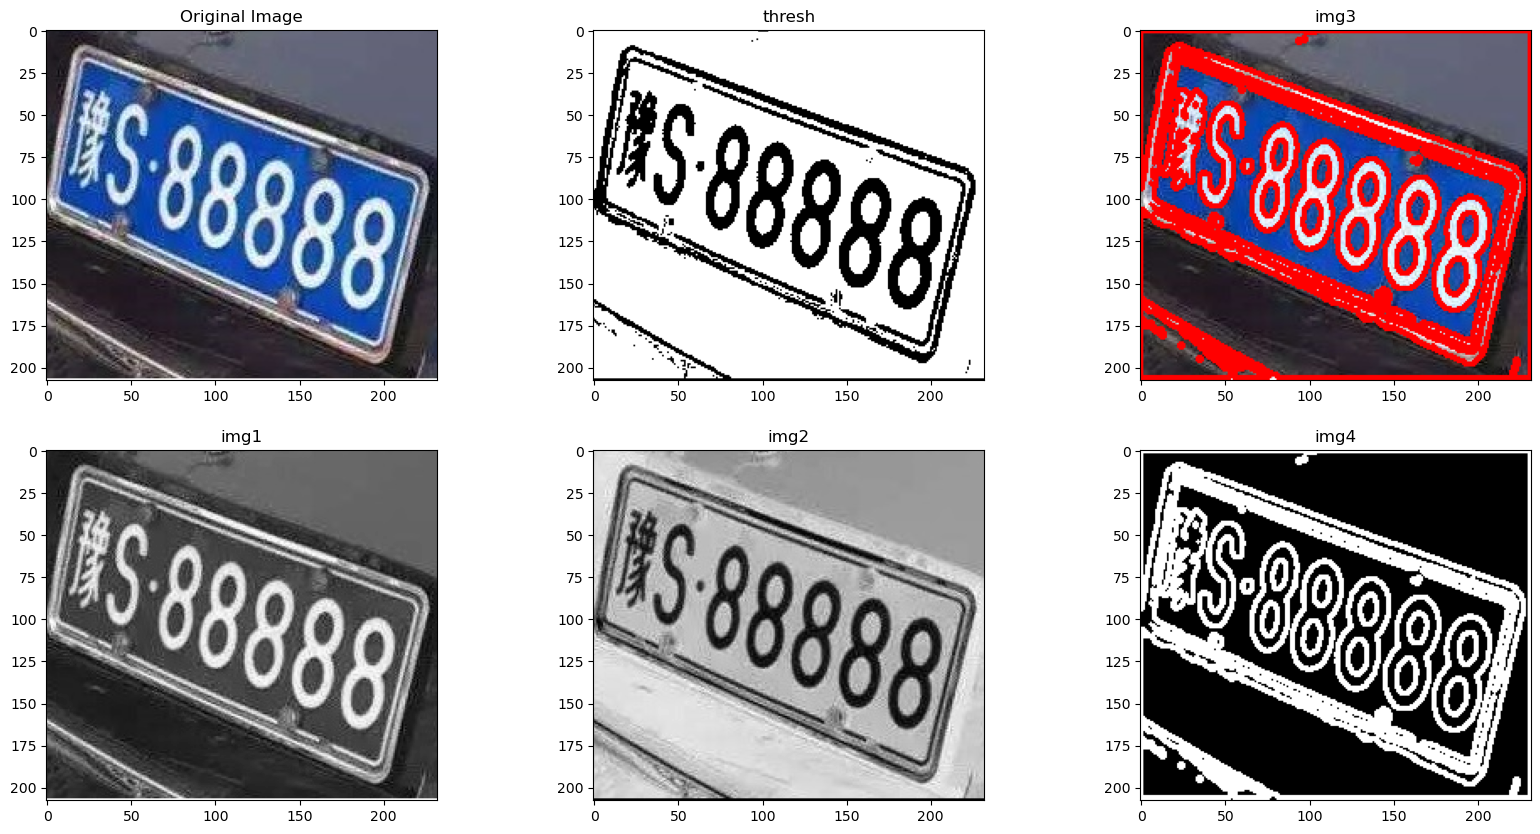

In [5]:
# 加载图像
img = cv.imread("./images/car3_plat.jpg")

# 转换为灰度图
img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做图像反转 (0 -> 255, 255 -> 0)
img2 = cv.bitwise_not(img1)

# 做二值化
ret, thresh = cv.threshold(img2, 127, 255, cv.THRESH_BINARY)

# 发现轮廓信息
# cv.RETR_LIST：检测所有轮廓但不建立层级关系
# CHAIN_APPROX_SIMPLE：对于一条直线上的点而言，仅仅保留端点信息
# contours：每个轮廓的坐标点信息
# hierarchy: 轮廓之间的关系
contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

# 在图像中绘制轮廓（红线）
img3 = np.copy(img)
# 当 contourIdx 为 -1 的时候，表示绘制所有轮廓
cv.drawContours(img3, contours, contourIdx=-1, color=(0, 0, 255), thickness=2)

# 绘制点最多的轮廓
# 计算点最多的轮廓的索引
# max_idx = np.argmax([len(t) for t in contours])
# cv.drawContours(img3, contours, contourIdx=max_idx, color=(0, 0, 255), thickness=2)

# 将轮廓当成边缘（白线）
img4 = np.zeros_like(img3)
# 当 contourIdx 为 -1 的时候，表示绘制所有轮廓
cv.drawContours(img4, contours, contourIdx=-1, color=(255, 255, 255), thickness=2)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(231)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(232)
plt.imshow(thresh, cmap='gray')  # 二值化
plt.title('thresh')

plt.subplot(233)
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))  # 在图像中绘制轮廓
plt.title('img3')

plt.subplot(234)
plt.imshow(img1, cmap='gray')  # 灰度图
plt.title('img1')

plt.subplot(235)
plt.imshow(img2, cmap='gray')  # 反转后的灰度图
plt.title('img2')

plt.subplot(236)
plt.imshow(img4, cmap='gray')  # 将轮廓当成边缘
plt.title('img4')

plt.show()

### 轮廓信息说明

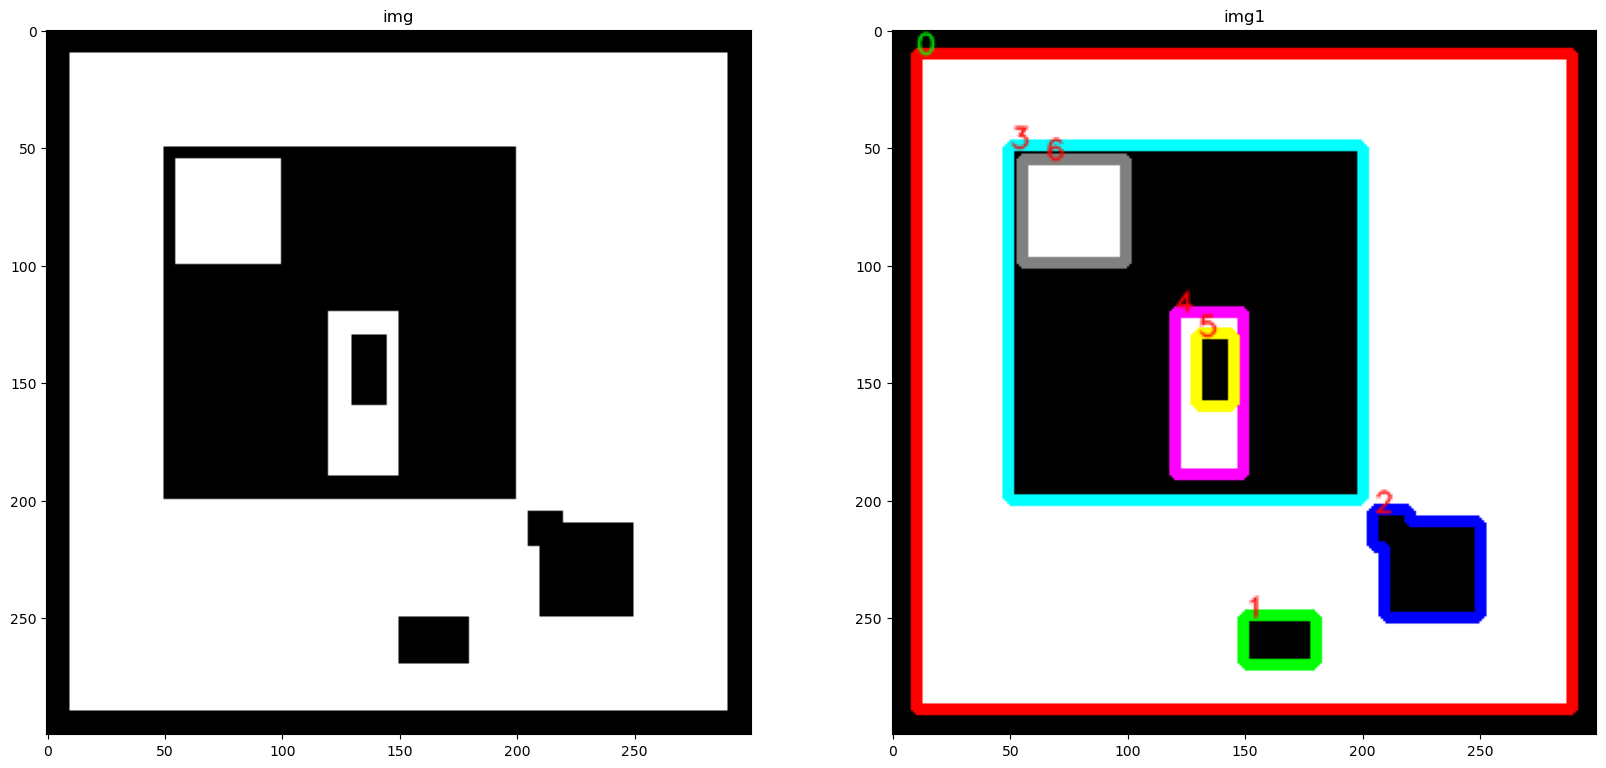

In [6]:
import copy

# 构建黑底白框的图像
img = np.zeros((300, 300), np.uint8)
img[10:290, 10:290] = 255
img[50:200, 50:200] = 0
img[55:100, 55:100] = 255
img[120:190, 120:150] = 255
img[130:160, 130:145] = 0
img[210:250, 210:250] = 0
img[250:270, 150:180] = 0
img[205:220, 205:220] = 0

img1 = np.copy(img)  # 拷贝图像

# 二值化
ret, thresh = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)

# 发现轮廓信息
# cv.RETR_TREE：检测所有轮廓并建立完整的层级树
# CHAIN_APPROX_SIMPLE：对于一条直线上的点而言，仅仅保留端点信息
# contours：每个轮廓的坐标点信息
# hierarchy: 轮廓直接的关系
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# 转换为 BGR 格式
bgr_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

# 在图像中绘制轮廓
# contourIdx=idx：绘制索引为 idx 的轮廓
cv.drawContours(bgr_img, contours, contourIdx=0, color=[255, 0, 0], thickness=3)  # 0红色
cv.drawContours(bgr_img, contours, contourIdx=1, color=[0, 255, 0], thickness=3)  # 1绿色
cv.drawContours(bgr_img, contours, contourIdx=2, color=[0, 0, 255], thickness=3)  # 2蓝色
cv.drawContours(bgr_img, contours, contourIdx=3, color=[0, 255, 255], thickness=3)  # 3青色
cv.drawContours(bgr_img, contours, contourIdx=4, color=[255, 0, 255], thickness=3)  # 4紫色
cv.drawContours(bgr_img, contours, contourIdx=5, color=[255, 255, 0], thickness=3)  # 5黄色
cv.drawContours(bgr_img, contours, contourIdx=6, color=[128, 128, 128], thickness=3)  # 6灰色

# 在图像中添加文本
# org=(10, 10)：宽度、高度
cv.putText(bgr_img, text='0', org=(10, 10), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(0, 255, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='1', org=(150, 250), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='2', org=(205, 205), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='3', org=(50, 50), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='4', org=(120, 120), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='5', org=(130, 130), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)
cv.putText(bgr_img, text='6', org=(65, 55), fontFace=cv.FONT_HERSHEY_SIMPLEX, fontScale=0.4, color=(255, 0, 0),
           thickness=1, lineType=cv.LINE_AA)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(img, 'gray')
plt.title('img')

plt.subplot(122)
plt.imshow(bgr_img, 'gray')  # 在图像中绘制轮廓
plt.title('img1')

plt.show()

In [7]:
print("总的轮廓数目：", len(contours))

colors = ["红色", "绿色", "蓝色", "青色", "紫色", "黄色", "灰色"]

# 遍历所有轮廓
for i in range(len(contours)):
    print(f"\n第 {i} 个轮廓（{colors[i]}）：\n", contours[i], sep="")

总的轮廓数目： 7

第 0 个轮廓（红色）：
[[[ 10  10]]

 [[ 10 289]]

 [[289 289]]

 [[289  10]]]

第 1 个轮廓（绿色）：
[[[149 250]]

 [[150 249]]

 [[179 249]]

 [[180 250]]

 [[180 269]]

 [[179 270]]

 [[150 270]]

 [[149 269]]]

第 2 个轮廓（蓝色）：
[[[204 205]]

 [[205 204]]

 [[219 204]]

 [[220 205]]

 [[220 209]]

 [[249 209]]

 [[250 210]]

 [[250 249]]

 [[249 250]]

 [[210 250]]

 [[209 249]]

 [[209 220]]

 [[205 220]]

 [[204 219]]]

第 3 个轮廓（青色）：
[[[ 49  50]]

 [[ 50  49]]

 [[199  49]]

 [[200  50]]

 [[200 199]]

 [[199 200]]

 [[ 50 200]]

 [[ 49 199]]]

第 4 个轮廓（紫色）：
[[[120 120]]

 [[120 189]]

 [[149 189]]

 [[149 120]]]

第 5 个轮廓（黄色）：
[[[129 130]]

 [[130 129]]

 [[144 129]]

 [[145 130]]

 [[145 159]]

 [[144 160]]

 [[130 160]]

 [[129 159]]]

第 6 个轮廓（灰色）：
[[[55 55]]

 [[55 99]]

 [[99 99]]

 [[99 55]]]


In [8]:
hierarchy
# 是一个[1, n, 4]格式，n为轮廓的数目
# 4：每个轮廓的 层级信息，由 4 个整数值组成，
# 具体含义：
# Next：同一层级中的下一个轮廓索引（-1 表示无）
# Previous：同一层级中的上一个轮廓索引（-1 表示无）
# First_Child：第一个子轮廓索引（-1 表示无）
# Parent：父轮廓索引（-1 表示无）
# 格式为：[Next, Previous, First_Child, Parent]

array([[[-1, -1,  1, -1],
        [ 2, -1, -1,  0],
        [ 3,  1, -1,  0],
        [-1,  2,  4,  0],
        [ 6, -1,  5,  3],
        [-1, -1, -1,  4],
        [-1,  4, -1,  3]]], dtype=int32)

In [9]:
# 1：轮廓检索模式下的 轮廓组数量
# 7：检测到的 轮廓总数
hierarchy.shape

(1, 7, 4)

### 轮廓属性
当获取得到轮廓坐标后，就可以基于轮廓来计算面积、周长等属性。

轮廓的形状(坐标点数量, 1, 坐标)：(1050, 1, 2)

轮廓数组：
[[[306 220]]

 [[306 229]]

 [[307 230]]

 ...

 [[307 244]]

 [[307 230]]

 [[306 229]]]


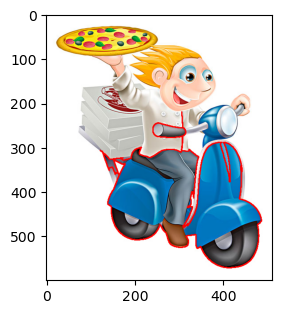

In [12]:
# 加载图像
img = cv.imread('./images/xiaoren.png')

# 转换为灰度图
img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做图像反转 (0 -> 255, 255 -> 0)
img1 = cv.bitwise_not(img1)

# 做二值化
ret, thresh = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)

# 发现轮廓信息
# RETR_LIST：检索所有轮廓，但是不保留层次信息
# HAIN_APPROX_SIMPLE：对于一条直线上的点而言，仅仅保留端点信息
# contours：每个轮廓的坐标点信息
# hierarchy: 轮廓直接的关系
contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

# 选择 1 个坐标点最多的轮廓进行处理
idx = np.argmax([len(t) for t in contours])
cnt = contours[idx]

# 绘制轮廓
# contourIdx=idx：绘制索引为 idx 的轮廓
cv.drawContours(img, contours, contourIdx=idx, color=(0, 0, 255), thickness=2)
print("轮廓的形状(坐标点数量, 1, 坐标)：", cnt.shape, sep="")
print("\n轮廓数组：\n", cnt, sep="")

plt.subplot(121)
plt.imshow(img[:, :, ::-1])
plt.show()

# 可视化
# cv.imshow('img', img)
# cv.waitKey(0)
# cv.destroyAllWindows()

In [13]:
# 计算面积
area = cv.contourArea(cnt)
# 计算周长
perimeter = cv.arcLength(cnt, closed=True)

print(f"面积：{area}")
print(f"周长：{perimeter}")

面积：65960.5
周长：2487.3636897802353


坐标x： 122
坐标y： 220

宽度： 365
高度： 353


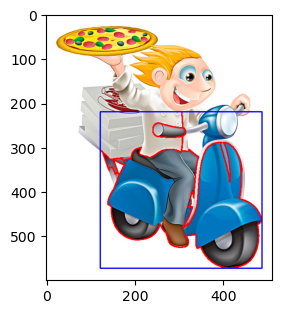

In [16]:
# 获取最大的矩形边缘框，返回值为矩形框的左上角的坐标，以及宽度和高度
x, y, w, h = cv.boundingRect(cnt)

# 绘图
# pt1=(x, y)：矩形框左上角的坐标
# pt2=(x + w, y + h)：右下角的坐标
cv.rectangle(img, pt1=(x, y), pt2=(x + w, y + h), color=(255, 0, 0), thickness=2)
print("坐标x：", x)
print("坐标y：", y)
print("\n宽度：", w)
print("高度：", h)

plt.subplot(121)
plt.imshow(img[:,:,::-1])
plt.show()

# 可视化
# cv.imshow('img', img)
# cv.waitKey(0)
# cv.destroyAllWindows()

最小矩形((x, y), (w, h), angle)：
((302.3465576171875, 419.5862731933594), (372.9076232910156, 317.0608215332031), 70.12313079833984)

从旋转矩形中提取其4个角点坐标：
[[ 89 298]
 [388 190]
 [514 541]
 [216 648]]


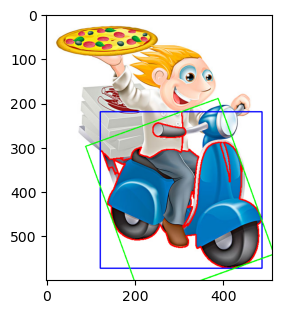

In [18]:
"""绘制最小矩形（所有边缘在矩形内）"""
# 得到矩形的点（左下角、左上角、右上角、右下角<顺序不一定>）、绘图

# minAreaRect：求得一个包含点集 cnt 的最小面积的矩形，这个矩形可以有一点旋转的，输出为矩形的四个坐标点
# rect为三元组：
# 第 1 个元素为旋转中心点的坐标
# 第 2 个元素为矩形的宽度和高度
# 第 3 个元素为旋转大小，正数表示顺时针旋转，负数表示逆时针旋转
rect = cv.minAreaRect(cnt)

# 从 旋转矩形 中提取其 4 个角点坐标
box = cv.boxPoints(rect)
# 转成整数
box = np.int64(box)

# [box]：要画的轮廓组
cv.drawContours(img, [box], contourIdx=0, color=(0, 255, 0), thickness=2)
# cv.polylines(img, [box], isClosed=True, color=(0, 255, 0), thickness=2)
print("最小矩形((x, y), (w, h), angle)：\n", rect, sep="")
print("\n从旋转矩形中提取其4个角点坐标：\n", box, sep="")

plt.subplot(121)
plt.imshow(img[:,:,::-1])
plt.show()

# cv.imshow('img', img)
# cv.waitKey(0)
# cv.destroyAllWindows()

x坐标： 294.0
y坐标： 428.0
半径： 210.29751586914062


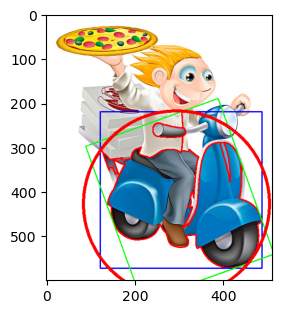

In [19]:
"""绘制最小的圆（所有边缘在圆内）"""

(x, y), radius = cv.minEnclosingCircle(cnt)
print("x坐标：", x)
print("y坐标：", y)
print("半径：", radius)
center = (int(x), int(y))
radius = int(radius)
cv.circle(img, center, radius, color=(0, 0, 255), thickness=5)

plt.subplot(121)
plt.imshow(img[:,:,::-1])
plt.show()

# 可视化
# cv.imshow('img', img)
# cv.waitKey(0)
# cv.destroyAllWindows()

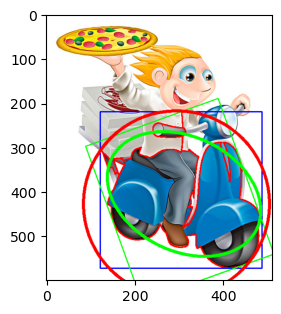

In [20]:
"""绘制最小的椭圆"""
# 所有边缘不一定均在圆内，一般不用
ellipse = cv.fitEllipse(cnt)
cv.ellipse(img, ellipse, color=(0, 255, 0), thickness=5)

plt.subplot(121)
plt.imshow(img[:,:,::-1])
plt.show()

# 可视化
# cv.imshow('img', img)
# cv.waitKey(0)
# cv.destroyAllWindows()

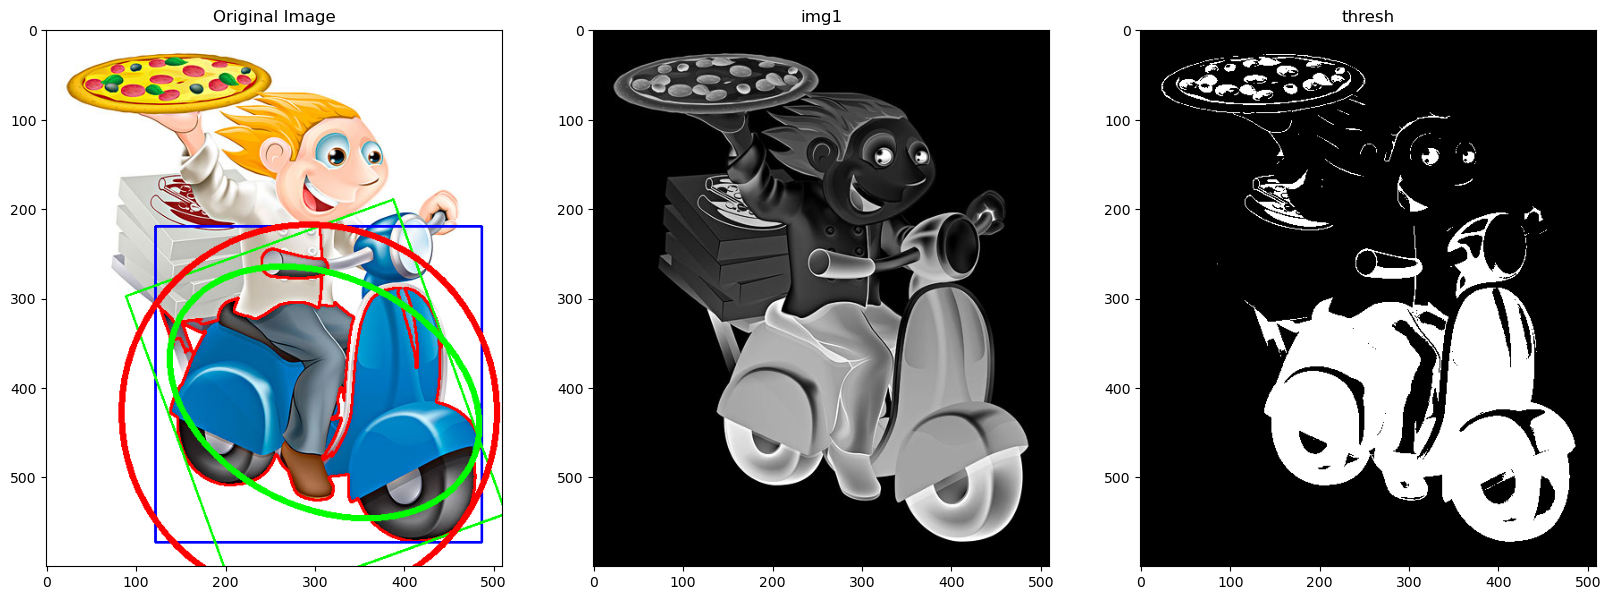

In [21]:
# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(131)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')  # 绘制轮廓外框的原图

plt.subplot(132)
plt.imshow(img1, cmap='gray')  # 反转后的灰度图
plt.title('img1')

plt.subplot(133)
plt.imshow(thresh, cmap='gray')  # 二值化
plt.title('thresh')

plt.show()

### 旋转后提取最小矩形

最小矩形((x, y), (w, h), angle)：
((302.5, 418.5), (317.0, 361.0), 0.0)

从旋转矩形中提取其4个角点坐标：
[[144 599]
 [144 238]
 [461 238]
 [461 599]]


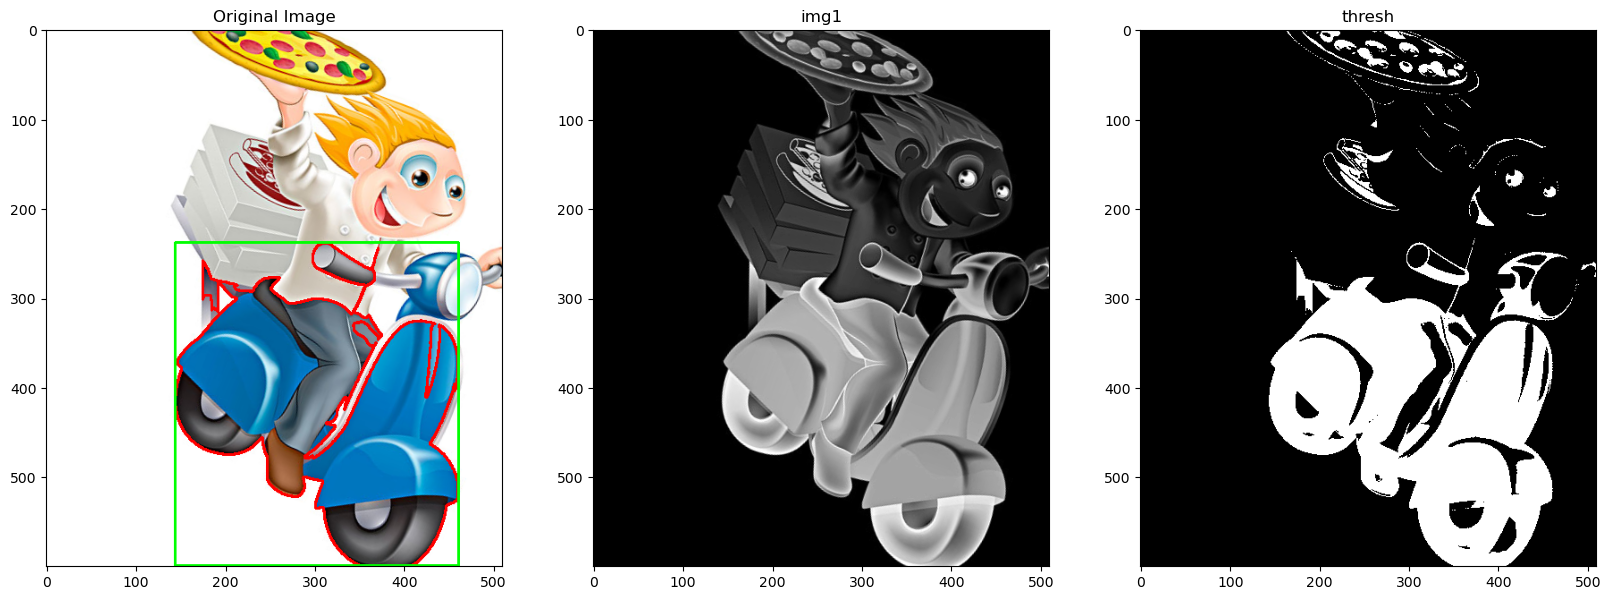

In [22]:
# 加载图像
img = cv.imread('./images/xiaoren.png')

# 旋转
# rect为三元组：
# 第 1 个元素为旋转中心点的坐标
# 第 2 个元素为矩形的宽度和高度
# 第 3 个元素为旋转大小，正数表示顺时针旋转，负数表示逆时针旋转
# ((x, y), (w, h), angle)
# ((302.3465576171875, 419.5862731933594), (372.9076232910156, 317.0608215332031), 70.12313079833984)
# 顺时针旋转 70 度，意味着矩形逆时针旋转 20 度
rect = [(302, 420), (372, 317), -20]

# 生成一个 2D 旋转矩阵
# angle：负数表示顺时针旋转
M = cv.getRotationMatrix2D(center=rect[0], angle=rect[-1], scale=1)
# 从灰度图的形状中提取高度、宽度
rows, cols = img[:, :, 0].shape
# 仿射变换
# borderValue=[255, 255, 255]：边界填充白色
img = cv.warpAffine(img, M, (cols, rows), borderValue=[255, 255, 255])

# 将图像转换为灰度图像
img1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 做图像反转（0 -> 255, 255 -> 0）
img1 = cv.bitwise_not(img1)

# 做二值化
ret, thresh = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)

# 发现轮廓信息
# RETR_LIST：检索所有轮廓，但是不保留层次信息
# HAIN_APPROX_SIMPLE：对于一条直线上的点而言，仅仅保留端点信息
# contours：每个轮廓的坐标点信息
# hierarchy: 轮廓直接的关系
contours, hierarchy = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

# 选择 1 个坐标点最多的轮廓进行处理
idx = np.argmax([len(t) for t in contours])
cnt = contours[idx]

# 绘制轮廓
# contourIdx=idx：绘制索引为 idx 的轮廓
cv.drawContours(img, contours, contourIdx=idx, color=(0, 0, 255), thickness=2)

# 绘制最小矩形（所有边缘在矩形内）
# minAreaRect：求得一个包含点集 cnt 的最小面积的矩形，这个矩形可以有一点的旋转的
# rect为三元组：
# 第 1 个元素为旋转中心点的坐标
# 第 2 个元素为矩形的宽度和高度
# 第 3 个元素为旋转大小，正数表示顺时针旋转，负数表示逆时针旋转
rect = cv.minAreaRect(cnt)

# 从 旋转矩形 中提取其 4 个角点坐标
box = cv.boxPoints(rect)
box = np.int64(box)

# [box]：要画的轮廓组
cv.drawContours(img, [box], contourIdx=0, color=(0, 255, 0), thickness=2)
print("最小矩形((x, y), (w, h), angle)：\n", rect, sep="")
print("\n从旋转矩形中提取其4个角点坐标：\n", box, sep="")

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(131)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')  # 旋转后的原图

plt.subplot(132)
plt.imshow(img1, cmap='gray')  # 反转后的灰度图
plt.title('img1')

plt.subplot(133)
plt.imshow(thresh, cmap='gray')  # 二值化
plt.title('thresh')

plt.show()

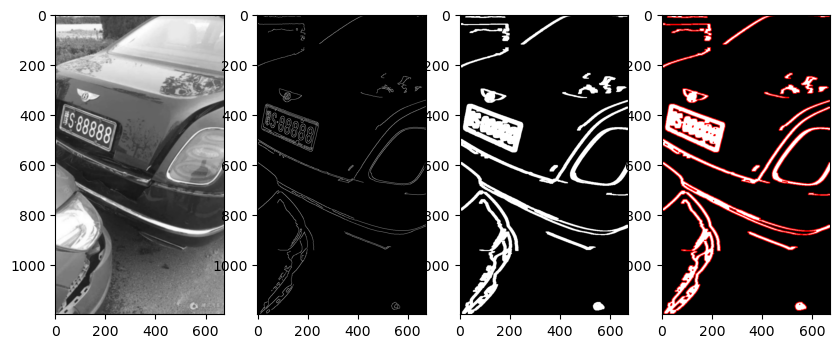

In [35]:
# 读取图像，car3.jpg
img = cv.imread("./images/car3.jpg")
# 转成灰度图
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# 高斯平滑去噪，核 (5, 5)，标准差 2
img = cv.GaussianBlur(img, (5, 5), 2)

# 边缘检测（返回二值化图像）
# threshold1=50, threshold2=250：低阈值、高阈值
img1 = cv.Canny(img, threshold1=50, threshold2=250)

# 膨胀操作
# 形状：(2, 5)，垂直方向膨胀少点，水平方向膨胀多点
kernel = np.asarray([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
])
img2 = cv.dilate(img1, kernel, iterations=3)

# 轮廓查找
# RETR_LIST：检索所有轮廓，但是不保留层次信息
# HAIN_APPROX_SIMPLE：对于一条直线上的点而言，仅仅保留端点信息
# contours：每个轮廓的坐标点信息
# hierarchy: 轮廓直接的关系
contours, hierarchy = cv.findContours(img2, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

# 拷贝图像
img3 = np.copy(img2)

# 转换为 BGR 格式
bgr_img = cv.cvtColor(img3, cv.COLOR_GRAY2BGR)

# 绘制轮廓
# contourIdx=-1：绘制所有轮廓
cv.drawContours(bgr_img, contours, contourIdx=-1, color=[0, 0, 255], thickness=2)

fig, axex = plt.subplots(1, 4, figsize=(10, 8), dpi=100)
axex[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axex[1].imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
axex[2].imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
axex[3].imshow(cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB))
plt.show()

# 可视化
# cv.imshow('img', img)
# cv.imshow('img1', img1)  # 边缘检测
# cv.imshow('img2', img2)  # 膨胀操作
# cv.imshow('bgr_img', bgr_img)  # 绘制轮廓
# cv.waitKey(0)
# cv.destroyAllWindows()


轮廓区域的面积：24208
最小外接矩形的面积：74675
面积比（轮廓区域/最小外接矩形）：0.32
最小外接矩形((x, y), (w, h), angle)：
((121.44227600097656, 977.0175170898438), (160.4650421142578, 465.36767578125), 8.736287117004395)

旋转矩形的4个角点坐标：
[[   6 1194]
 [  77  734]
 [ 236  759]
 [ 165 1219]]


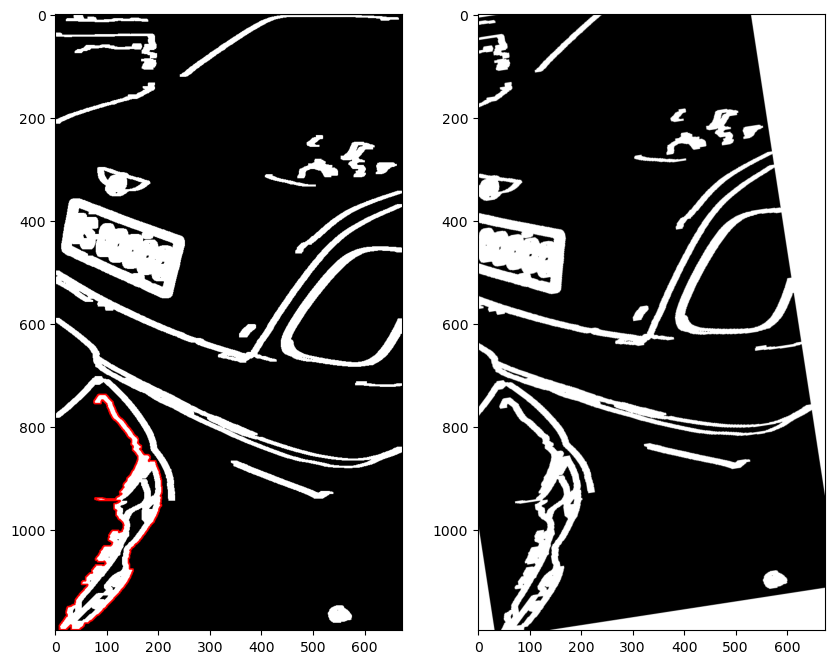


轮廓区域的面积：11327
最小外接矩形的面积：175397
面积比（轮廓区域/最小外接矩形）：0.06
最小外接矩形((x, y), (w, h), angle)：
((358.0018005371094, 558.078857421875), (254.6942901611328, 688.6602783203125), 78.98951721191406)

旋转矩形的4个角点坐标：
[[ -4 498]
 [671 367]
 [720 617]
 [ 44 748]]


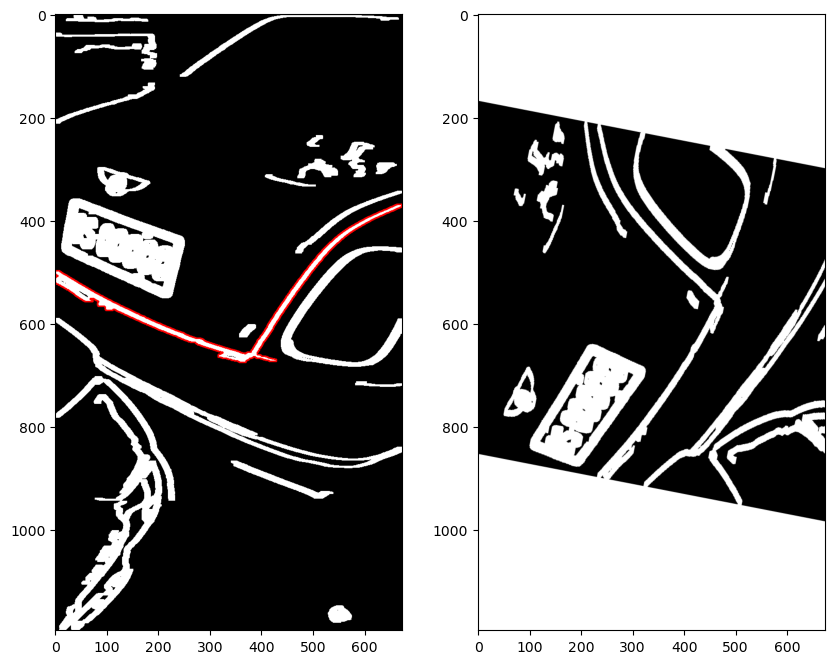


轮廓区域的面积：27614
最小外接矩形的面积：31692
面积比（轮廓区域/最小外接矩形）：0.87
最小外接矩形((x, y), (w, h), angle)：
((127.27120971679688, 454.2657775878906), (250.6768341064453, 126.42582702636719), 20.27557945251465)

旋转矩形的4个角点坐标：
[[-12 470]
 [ 31 351]
 [266 438]
 [222 556]]


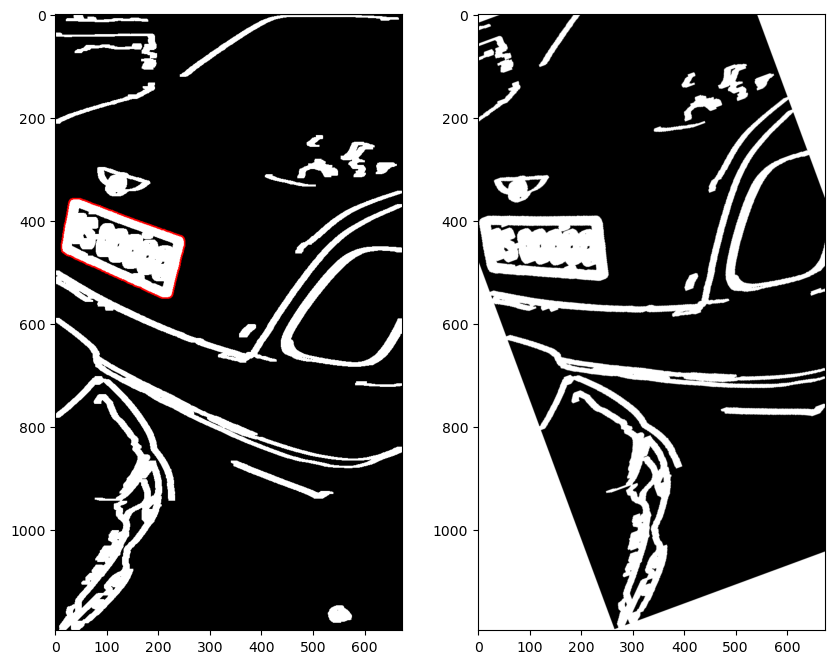

In [36]:
"""处理图像中的轮廓，筛选出符合条件的轮廓，并对其进行旋转校正和可视化"""

img5 = np.copy(img3)  # 拷贝图像
rows, cols = img5.shape  # 提取高度、宽度

cont_idx = 0  # 初始化轮廓索引

# 针对所有找到的轮廓进行遍历0
for cnt in contours:
    cont_idx += 1
    rect = cv.minAreaRect(cnt)  # 最小外接矩形 ((x, y), (w, h), angle)
    w, h = rect[1]  # 最小外接矩形的宽度和高度

    if w < 50 or h < 50:  # 排除过小的矩形
        continue
    r = w / h
    if r > 4 or r < 1 / 4:  # 排除长宽比异常的矩形
        continue
    area = cv.contourArea(cnt)  # 轮廓区域的面积
    if area < 10000:  # 排除面积过小的轮廓
        continue
    area2 = w * h  # 最小外接矩形的面积

    # 旋转
    # 生成一个 2D 旋转矩阵
    M = cv.getRotationMatrix2D(center=rect[0], angle=rect[-1], scale=1)
    # 仿射变换
    # borderValue=[255, 255, 255]：边界填充白色
    img6 = cv.warpAffine(img5, M, (cols, rows), borderValue=[255, 255, 255])

    print("\n=========================")
    print(f"轮廓区域的面积：{int(area)}")
    print(f"最小外接矩形的面积：{int(area2)}")
    print(f"面积比（轮廓区域/最小外接矩形）：{area / area2:.2f}")  # 旋转面积比最大的，例如大于 50%，可能就是我们要找的区域
    print("最小外接矩形((x, y), (w, h), angle)：\n", rect, sep="")

    # 从 旋转矩形 中提取其 4 个角点坐标
    box = cv.boxPoints(rect)
    box = np.int64(box)
    print("\n旋转矩形的4个角点坐标：\n", box, sep="")

    # 转换为 BGR（3 通道）
    bgr_img = cv.cvtColor(img5, cv.COLOR_GRAY2BGR)

    # 绘制轮廓
    # contourIdx=cont_idx - 1：绘制第 cont_idx - 1 个轮廓
    cv.drawContours(bgr_img, contours, contourIdx=cont_idx - 1, color=[0, 0, 255], thickness=2)

    fig, axex = plt.subplots(1, 2, figsize=(10, 8), dpi=100)
    axex[0].imshow(cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB))
    axex[1].imshow(cv.cvtColor(img6, cv.COLOR_BGR2RGB))
    plt.show()

    # 可视化
    # cv.imshow('bgr_img', bgr_img)  # 绘制轮廓后的图像
    # cv.imshow('img6', img6)  # 仿射变换后的图像
    # cv.waitKey(0)
    # cv.destroyAllWindows()